# For random graphs we want to plot

## Imports

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import sqrt, log, e, pi
from scipy.stats import norm
from statistics import NormalDist
import pickle
from utils import * 
import random
import csv

## For N**20
plot vanilla approximations for now
- expected
- approximation
- actual

In [52]:
N = 2 ** 20
p = 1 - e**(-2) # our table coverage
t = round(log(1-p)/log(1-N**(-1/3)))
alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

### Simulate cherry tables 

In [53]:
# return optimum K and mt
optimisation_kis = []
optimisation_mt = []
optimisation_costs = []
optimisation_results = []
# for each alpha, run optimisation
for alpha in alphas:
    # run the optimisation
    kis, m_0, final_cost, m_values = optimise_kj(N, p, alpha, 5, 1)
    optimisation_kis.append(kis)
    # adjust the simulation results and store
    adjusted_m, adjusted_cost = adjust_simulation(m_values, final_cost, N)
    m_values.append(adjusted_m)
    result = [kis, m_0, final_cost, m_values]
    optimisation_results.append(result)
    optimisation_costs.append(final_cost)
    # store the simulated m_t
    optimisation_mt.append(adjusted_m)

# store optimisation_results in a pickle file
with open("cherry_N_20_different_alpha_0.5_0.95_optimisation_results.pkl", "wb") as f:
    pickle.dump(optimisation_results, f)


Optimization terminated successfully    (Exit mode 0)
            Current function value: -7296.306632094935
            Iterations: 17
            Function evaluations: 3451
            Gradient evaluations: 17
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7936.99922748669
            Iterations: 18
            Function evaluations: 3655
            Gradient evaluations: 18
Optimization terminated successfully    (Exit mode 0)
            Current function value: -8563.312703109552
            Iterations: 17
            Function evaluations: 3451
            Gradient evaluations: 17
Optimization terminated successfully    (Exit mode 0)
            Current function value: -9176.348928308455
            Iterations: 17
            Function evaluations: 3452
            Gradient evaluations: 17
Optimization terminated successfully    (Exit mode 0)
            Current function value: -9776.21574584025
            Iterations: 21
            Functi

In [54]:
# build the tables using the results
samples = 10
generation_results = []
generation_mt = []
generation_costs = []
startpoint_sets = []

for a, alpha in enumerate(alphas):
    # build the actual table - 100 times 
    # first generate starpoints and store them
    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0
    this_alpha_startpoints = []
    # generate sample sets of starpoints
    for i in range(samples):
        starpoints = set()
        while len(starpoints) < (cherry_m_0):
            starpoints.add(random.randint(0, N-1))

        this_alpha_startpoints.append(starpoints)
    # append to main list
    startpoint_sets.append(this_alpha_startpoints)

    ##############################################################

    # build the cherry table sample times and store it for later
    this_alpha_tables = []
    this_alpha_mt = []
    this_alpha_costs = []

    # get the optimisation kis for this alpha
    optimisation_kis_for_alpha = optimisation_kis[a]

    # build sample tables
    for i in range(samples):
        # get starpoints
        starpoints = this_alpha_startpoints[i]
        # make the table with these startpoints
        table, rf_indexes, hashes, reductions, duration = build_cherry_table(N, t, starpoints, optimisation_kis_for_alpha)
        # append to this alpha's tables
        this_alpha_tables.append((table, rf_indexes))
        this_alpha_mt.append(len(table))
        this_alpha_costs.append(hashes + (reductions * 1/577.44))  # total cost is hashes + reductions * 1/577.44
    
    # append to main list
    generation_results.append(this_alpha_tables)
    generation_mt.append(this_alpha_mt)
    generation_costs.append(this_alpha_costs)

###################################################################

# store in a csv file
with open("cherry_N_20_10_trials_different_alpha_0.5_0.95_with_cost_results.csv", "w", newline='') as f:
    f_alpha = csv.writer(f) # create a csv writer

    # create a list of headers for the different trials
    trial_headers = []
    cost_headers = []
    for i in range(samples):
        trial_headers.append(f"trial_{i+1}")
        cost_headers.append(f"cost_{i+1}")
    
    f_alpha.writerow(["alpha", "optimiser_mt"] + trial_headers  + ["optimiser_cost"] + cost_headers)

    # add in data for each alpha
    for i in range(len(alphas)):
        row = [alphas[i], optimisation_mt[i]] + generation_mt[i] + [optimisation_costs[i]] + generation_costs[i]
        f_alpha.writerow(row)

Calculating columns:  48%|████▊     | 97/202 [17:23<18:50, 10.76s/it]


KeyboardInterrupt: 

### Sampling Functions

In [ ]:
def get_mean(N, m):
    return N - (N*(1 - 1/N)**m)

def get_std(N, m):
    # E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m

    return sqrt(N * (((N - 1) * E2) + E1 - (N * (E1 ** 2))))

# Cherry Table Simulation - only returns number of endpoints
def cherry_table_simulation(N, t, K, startpoints_len):

    m = startpoints_len

    # for each column
    for i in range(len(K)):
        # get the mean (loc)
        # get the standard deviation (scale)
        mean = get_mean(N, m)
        std = get_std(N, m)
        # get distribution of the current column
        column_dist = norm(loc=mean, scale=std)
        # for the next column, we want to sample K times and use the maximum
        samples = column_dist.rvs(size=round(K[i]))
        # set m to be the maximum of these samples
        m = max(samples)


    return m

### Get samples

In [ ]:


cherry_sample_simulated_mts = []

# get kis for each alpha
with open("cherry_N_20_different_alpha_0.5_0.95_optimisation_results.pkl", "rb") as f:
    optimisation_results = pickle.load(f)

K = [optimisation_results[i][0] for i in range(len(alphas))]

for alpha in alphas:

    mts = []

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0

    # get the kis for this alpha
    kis_for_alpha = K[alphas.index(alpha)]

    # run 100 simulations
    for _ in range(100):
        mt = cherry_table_simulation(N, t, kis_for_alpha, cherry_m_0)
        mts.append(mt)

    cherry_sample_simulated_mts.append(mts)
    


Couldn't find program: 'false'


In [ ]:

# do sampling for vanilla tables as well
vanilla_sample_simulated_mts = []
K = [1 for i in range(t)]  # all kis are 1 for vanilla tables

for alpha in alphas:

    mts = []

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    vanilla_m_0 = round(mt_target/(1-alpha))    # our starting m_0

    # run 100 simulations
    for _ in range(100):
        mt = cherry_table_simulation(N, t, K, vanilla_m_0)
        mts.append(mt)

    vanilla_sample_simulated_mts.append(mts)


# # plot the vanilla sampling method too as a boxplot
# plt.boxplot(vanilla_sample_simulated_mts, 
#             positions=[i for i in x_indicies], widths=0.5,
#             boxprops=dict(color='darkgreen'),  
#             medianprops=dict(color='darkgreen'),
#             whiskerprops=dict(color='darkgreen'),
#             capprops=dict(color='darkgreen'),
#             flierprops=dict(markerfacecolor='darkgreen', marker='o', markersize=5, markeredgecolor='none'))
# # plot means of vanilla sampling boxplots
# plt.plot([i for i in x_indicies], [np.mean(vanilla_sample_simulated_mts[a]) for a in range(len(alphas))], 
#          color='darkgreen', linestyle='--', label='Vanilla Sampled $m_t$')

### Expected

In [ ]:
# get expected mts for vanilla tables
# calculate expected m_t
expected_mts = []
# mt-max = 2N/t+2
# mt = alpha * mt-max
t = round(log(1-p)/log(1-N**(-1/3)))
mt_max = (2*N)/(t + 2)
for alpha in alphas:
    expected_mts.append(round(alpha * mt_max))

### Approximate

In [ ]:
def approximate_mt(N, t, K, m_0):
    m = m_0  # starting m value

    # for the number of columns
    for i in range(t):
        # Calculate E1 and E2
        E1 = (1 - 1 / N) ** m
        E2 = (1 - 2 / N) ** m

        # calculate the statistical average of m_i
        average = N * (1 - E1)

        # find variance, and thus standard deviation
        if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:   # this equation gives the variance, so sqrt to get standard deviation
            # if it is negative (error), set it to 0
            sd = 0
        else:
            # count the statistical variance of m_i+1 otherwise
            sd = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))

        # expectance of maximum of K samples 
        m = average + NormalDist().inv_cdf((K[i] - pi / 8) / (K[i] - pi / 4 + 1)) * sd

    return m

In [ ]:
# get approximation results
approximation_mt = []
K = [1 for i in range(t)]  # all kis are 1 for vanilla tables
for alpha in alphas:

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    m_0 = round(mt_target/(1-alpha))    # our starting m_0

    approximation_mt.append(approximate_mt(N, t, K, m_0))

In [ ]:
# get approximation results for cherry tables
approximation_cherry_mt = []
for a, alpha in enumerate(alphas):

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    m_0 = round(mt_target/(1-alpha))    # our starting m_0

    # get the kis for this alpha
    kis_for_alpha = optimisation_kis[a]

    approximation_cherry_mt.append(approximate_mt(N, t, kis_for_alpha, m_0))

### Actual and Plot

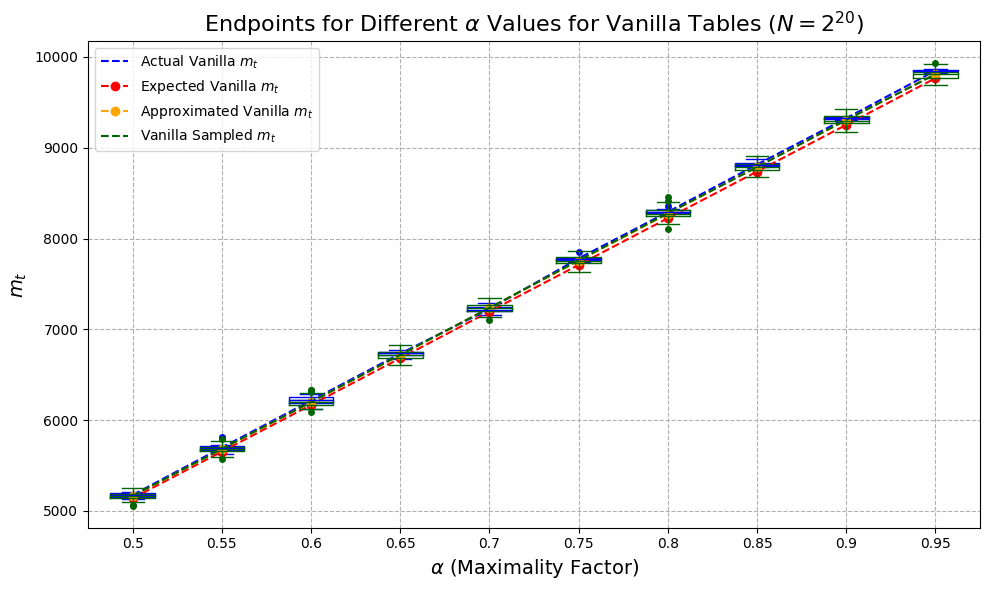

In [ ]:
# plot scatter plot of optimisation mt vs generated mt
x_indicies = range(len(alphas))
plt.figure(figsize=(10,6))

###################################################################################################################################

# plot actual for vanilla tables as well
data_vanilla = pd.read_csv("vanilla_N_20_alpha_0.5_0.95_with_cost_results.csv")
x_indicies = range(len(alphas))
# for actual vanilla - convert samples from dataframe to a single list for boxplot
plt.boxplot([data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[1:11]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='blue'),
            medianprops=dict(color='blue'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(markerfacecolor='blue', marker='o', markersize=5, markeredgecolor='none'))
# plot means of vanilla boxplots
plt.plot(x_indicies, [data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[1:11]].values.flatten().mean() for alpha in alphas], 
         color='blue', linestyle='--', label='Actual Vanilla $m_t$')

# plot expected vanilla mt in green
plt.plot(x_indicies, expected_mts, color='red', label='Expected Vanilla $m_t$', marker='o', linestyle='--')

# plot approximation mt in orange
plt.plot(x_indicies, approximation_mt, color='orange', label='Approximated Vanilla $m_t$', marker='o', linestyle='--')

# plot the vanilla sampling method too as a boxplot
plt.boxplot(vanilla_sample_simulated_mts, 
            positions=[i for i in x_indicies], widths=0.5,
            boxprops=dict(color='darkgreen'),  
            medianprops=dict(color='darkgreen'),
            whiskerprops=dict(color='darkgreen'),
            capprops=dict(color='darkgreen'),
            flierprops=dict(markerfacecolor='darkgreen', marker='o', markersize=5, markeredgecolor='none'))
# plot means of vanilla sampling boxplots
plt.plot([i for i in x_indicies], [np.mean(vanilla_sample_simulated_mts[a]) for a in range(len(alphas))], 
         color='darkgreen', linestyle='--', label='Vanilla Sampled $m_t$')

###################################################################################################################################

# plot actual cherry mt from csv as boxplot
data_cherry = pd.read_csv("cherry_N_20_10_trials_different_alpha_0.5_0.95_with_cost_results.csv")
plt.boxplot([data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[2:12]].values.flatten() for alpha in alphas],
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='orange'),
            medianprops=dict(color='orange'),
            whiskerprops=dict(color='orange'),
            capprops=dict(color='orange'),
            flierprops=dict(markerfacecolor='orange', marker='o', markersize=5, markeredgecolor='none'))
# plot means of cherry boxplots
plt.plot([i for i in x_indicies], [np.mean(data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[2:12]].values.flatten()) for alpha in alphas], 
         color='orange', linestyle='--', label='Actual Cherry $m_t$')
# plot cherry sampling method too as boxplot
plt.boxplot(cherry_sample_simulated_mts,
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='darkorange'),
            medianprops=dict(color='darkorange'),
            whiskerprops=dict(color='darkorange'),
            capprops=dict(color='darkorange'),
            flierprops=dict(markerfacecolor='darkorange', marker='o', markersize=5, markeredgecolor='none'))
# plot means of cherry sampling boxplots
plt.plot([i for i in x_indicies], [np.mean(cherry_sample_simulated_mts[a]) for a in range(len(alphas))], 
         color='darkorange', linestyle='--', label='Cherry Sampled $m_t$')
# plot cherry approximation mt in purple
plt.plot(x_indicies, approximation_cherry_mt, color='purple', label='Approximated Cherry $m_t$', marker='o', linestyle='--')

###################################################################################################################################

# titles and labels
plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$', fontsize=14)
plt.xticks(x_indicies, alphas)
plt.grid(linestyle="--")
plt.title('Endpoints for Different $\\alpha$ Values for Vanilla Tables ($N=2^{20}$)', fontsize=16)

# manually add legend
box_legend = mpatches.Patch(color="blue", label="Vanilla Actual $m_t$")
plt.legend()


plt.tight_layout()  
plt.show()